In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve, accuracy_score, confusion_matrix
from sklearn.calibration import CalibrationDisplay
from nilearn import plotting
from nilearn.plotting import view_markers
from IPython.display import display



In [2]:
# ============================================================
# 0) REPRODUCTIBILITÉ (SEED FIXE)
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ============================================================
# CONFIGURATION
# ============================================================
DATA_PATH = "../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv"
ATLAS_NII = "/scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.nii.gz"
ATLAS_TSV = "/scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.tsv"
# CHANGEMENT ICI : Dossier de sortie distinct pour Ridge
OUTPUT_DIR = "../results_loso_ridge_final"

CONF_METHOD = "regression"
INCLUDE_CONFOUNDS_IN_MODEL = False
conf_vars = ["age", "gender_num", "mean_fd"]

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)



In [3]:
# ============================================================
# 1) CHARGEMENT
# ============================================================
print(f"--- Chargement : {DATA_PATH} ---")
df_all = pd.read_csv(DATA_PATH, sep="\t")

mask_loso = (
    df_all["site_id"].isin(["ds000030", "ds_cobre", "ds004302"])
    & df_all["diagnosis"].isin(["CONTROL", "SCHZ"])
)
df_loso = df_all.loc[mask_loso].copy()

# Variables cliniques
df_loso["age"] = df_loso["age"].astype(float)
df_loso["gender_num"] = (df_loso["gender"] == "M").astype(float)

if "mean_fd" not in df_loso.columns:
    df_loso["mean_fd"] = 0.0
else:
    df_loso["mean_fd"] = df_loso["mean_fd"].astype(float)
    if df_loso["mean_fd"].isna().any():
        df_loso["mean_fd"] = df_loso["mean_fd"].fillna(df_loso["mean_fd"].median())

y_loso_all = (df_loso["diagnosis"] == "SCHZ").astype(int)
groups_loso = df_loso["site_id"].values



--- Chargement : ../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv ---


/tmp/ipykernel_850005/994058128.py:5: DtypeWarning: Columns (93968) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(DATA_PATH, sep="\t")


In [4]:
# ============================================================
# 2) CONNECTOMES (RAW)
# ============================================================
corr_cols_all = [c for c in df_loso.columns if c.startswith("corr_")]
X_temp = df_loso[corr_cols_all]
corr_cols = X_temp.columns[X_temp.notna().any()].tolist()
X_loso_raw = df_loso[corr_cols]



In [5]:
# ============================================================
# 3) FONCTIONS
# ============================================================

def residualize_confounds(X_train, X_test, conf_train, conf_test):
    imp = SimpleImputer(strategy="mean")
    X_train_imp = imp.fit_transform(X_train)
    X_test_imp = imp.transform(X_test)
    
    C_train = np.column_stack([np.ones(len(conf_train)), conf_train.values])
    C_test  = np.column_stack([np.ones(len(conf_test)),  conf_test.values])
    
    B = np.linalg.pinv(C_train).dot(X_train_imp)
    
    return (pd.DataFrame(X_train_imp - C_train.dot(B), index=X_train.index, columns=X_train.columns),
            pd.DataFrame(X_test_imp - C_test.dot(B), index=X_test.index, columns=X_test.columns))

def get_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="mean")), 
        ("scaler", StandardScaler()), 
        ("clf", LogisticRegressionCV(
            cv=5, 
            penalty='l2',        # CHANGEMENT ICI : L2 (Ridge)
            solver='liblinear',  # 'liblinear' gère bien L1 et L2. Pour L2, 'lbfgs' est aussi commun.
            scoring='roc_auc', 
            class_weight='balanced', 
            max_iter=5000, 
            n_jobs=-1, 
            random_state=RANDOM_SEED
        ))
    ])

def calculate_youden_metrics(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    J = tpr - fpr
    ix = np.argmax(J)
    best_thresh = thresholds[ix]
    
    y_pred = (y_prob >= best_thresh).astype(int)
    acc = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return best_thresh, acc, sens, spec, fpr[ix], tpr[ix]


DÉBUT LOSO (REAL DATA) | RIDGE (L2) | Seed=42

🔹 SITE TEST : ds000030
   AUC Interne : 0.741
   AUC Externe : 0.684  (Brier: 0.227)
   Youden Thresh: 0.55 | Acc: 0.674 | Sens: 0.660 | Spec: 0.680

🔹 SITE TEST : ds004302
   AUC Interne : 0.579
   AUC Externe : 0.737  (Brier: 0.187)
   Youden Thresh: 0.63 | Acc: 0.761 | Sens: 0.804 | Spec: 0.680

🔹 SITE TEST : ds_cobre
   AUC Interne : 0.595
   AUC Externe : 0.754  (Brier: 0.203)
   Youden Thresh: 0.51 | Acc: 0.705 | Sens: 0.764 | Spec: 0.649


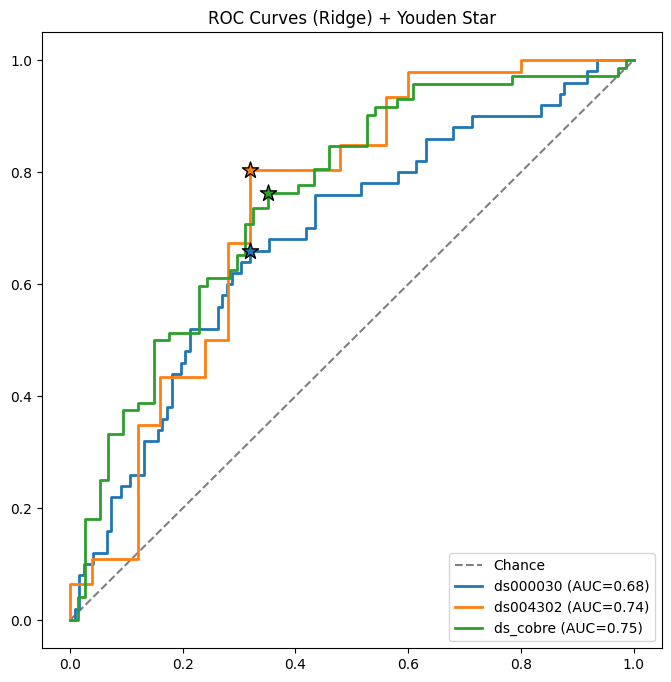

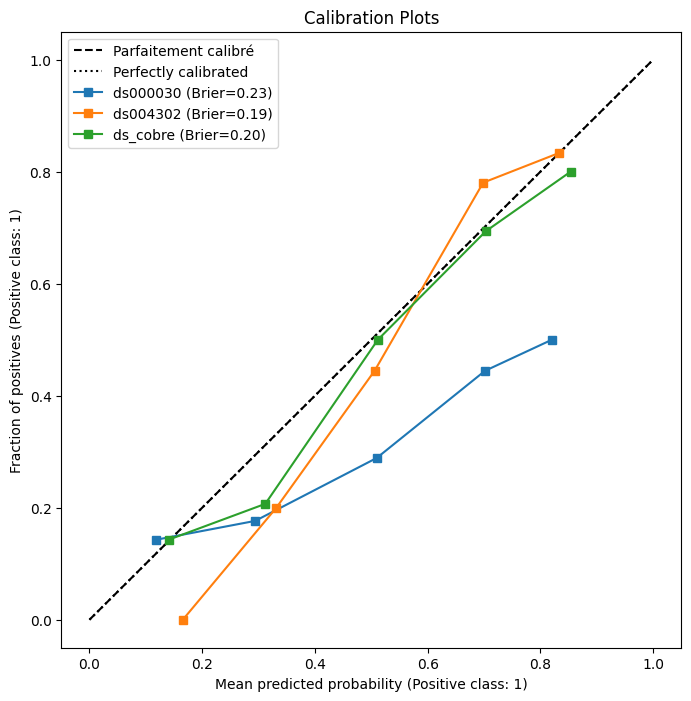

In [6]:
# ============================================================
# 4) BOUCLE LOSO
# ============================================================
print("\n" + "="*60)
# CHANGEMENT ICI : Log
print(f"DÉBUT LOSO (REAL DATA) | RIDGE (L2) | Seed={RANDOM_SEED}")
print("="*60)

logo = LeaveOneGroupOut()
loso_results = []
all_weights_data = []

fig_roc, ax_roc = plt.subplots(figsize=(8, 8))
ax_roc.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
fig_cal, ax_cal = plt.subplots(figsize=(8, 8))
ax_cal.plot([0, 1], [0, 1], "--", color="black", label="Parfaitement calibré")
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (train_idx, test_idx) in enumerate(logo.split(X_loso_raw, y_loso_all, groups=groups_loso)):
    site_test_name = groups_loso[test_idx][0]
    print(f"\n🔹 SITE TEST : {site_test_name}")
    
    # 1. Split
    X_tr, X_te = X_loso_raw.iloc[train_idx], X_loso_raw.iloc[test_idx]
    y_tr, y_te = y_loso_all.iloc[train_idx], y_loso_all.iloc[test_idx]
    c_tr, c_te = df_loso.iloc[train_idx][conf_vars], df_loso.iloc[test_idx][conf_vars]

    # 2. Correction
    if CONF_METHOD == "regression":
        X_tr_cl, X_te_cl = residualize_confounds(X_tr, X_te, c_tr, c_te)
    else:
        X_tr_cl, X_te_cl = X_tr, X_te

    # 3. Fit
    pipeline = get_model()
    pipeline.fit(X_tr_cl, y_tr)
    
    # AUC CV Interne
    clf_obj = pipeline.named_steps['clf']
    best_c_val = clf_obj.C_[0]
    best_c_idx = np.where(clf_obj.Cs_ == best_c_val)[0][0]
    auc_internal = clf_obj.scores_[1][:, best_c_idx].mean()

    # 4. Predict
    y_prob = pipeline.predict_proba(X_te_cl)[:, 1]
    
    # 5. Metrics
    auc_external = roc_auc_score(y_te, y_prob)
    brier = brier_score_loss(y_te, y_prob) # Score de calibration
    
    thresh, acc, sens, spec, b_fpr, b_tpr = calculate_youden_metrics(y_te, y_prob)
    
    delta = auc_internal - auc_external
    print(f"   AUC Interne : {auc_internal:.3f}")
    print(f"   AUC Externe : {auc_external:.3f}  (Brier: {brier:.3f})")
    print(f"   Youden Thresh: {thresh:.2f} | Acc: {acc:.3f} | Sens: {sens:.3f} | Spec: {spec:.3f}")

    loso_results.append({
        "site": site_test_name, 
        "auc_internal": auc_internal,
        "auc_external": auc_external,
        "delta_auc": delta,
        "brier_score": brier,
        "accuracy": acc, 
        "sensitivity": sens, 
        "specificity": spec, 
        "optimal_threshold": thresh
    })

    # Plots
    color = colors[i % 3]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    ax_roc.plot(fpr, tpr, color=color, lw=2, label=f"{site_test_name} (AUC={auc_external:.2f})")
    ax_roc.scatter(b_fpr, b_tpr, color=color, s=150, marker='*', edgecolors='k', zorder=10)
    
    CalibrationDisplay.from_predictions(y_te, y_prob, n_bins=5, name=f"{site_test_name} (Brier={brier:.2f})", ax=ax_cal, color=color)

    # Weights
    features_kept = pipeline[:-1].get_feature_names_out()
    coeffs = clf_obj.coef_.flatten()
    
    fold_weights_df = pd.DataFrame(index=X_tr_cl.columns)
    fold_weights_df["weight"] = 0.0 
    fold_weights_df["status"] = "Excluded_by_Imputer"
    fold_weights_df.loc[features_kept, "weight"] = coeffs
    fold_weights_df.loc[features_kept, "status"] = "Kept"
    fold_weights_df["test_site"] = site_test_name
    fold_weights_df["feature_name"] = fold_weights_df.index
    all_weights_data.append(fold_weights_df)

# CHANGEMENT ICI : Titre ROC
ax_roc.set_title("ROC Curves (Ridge) + Youden Star")
ax_roc.legend(loc='lower right')
ax_cal.set_title("Calibration Plots")
ax_cal.legend(loc='upper left')
plt.show()



In [ ]:
# ============================================================
# 5) SANITY CHECK
# ============================================================
print("\n" + "="*60)
print(f"DÉBUT SANITY CHECK (LABELS ALÉATOIRES)")
print("="*60)

np.random.seed(RANDOM_SEED + 99) 
y_rand = pd.Series(np.random.permutation(y_loso_all), index=df_loso.index)
rand_results = []

for i, (train_idx, test_idx) in enumerate(logo.split(X_loso_raw, y_rand, groups=groups_loso)):
    site_test_name = groups_loso[test_idx][0]
    X_tr, X_te = X_loso_raw.iloc[train_idx], X_loso_raw.iloc[test_idx]
    y_tr, y_te = y_rand.iloc[train_idx], y_rand.iloc[test_idx]
    c_tr, c_te = df_loso.iloc[train_idx][conf_vars], df_loso.iloc[test_idx][conf_vars]
    
    if CONF_METHOD == "regression":
        X_tr_cl, X_te_cl = residualize_confounds(X_tr, X_te, c_tr, c_te)
    else:
        X_tr_cl, X_te_cl = X_tr, X_te
        
    pipeline = get_model()
    pipeline.fit(X_tr_cl, y_tr)
    y_prob = pipeline.predict_proba(X_te_cl)[:, 1]
    
    auc_r = roc_auc_score(y_te, y_prob)
    print(f"   Site {site_test_name} | AUC Random: {auc_r:.3f}")
    rand_results.append({"site": site_test_name, "auc_random": auc_r})

print(f"Moyenne AUC Random : {pd.DataFrame(rand_results)['auc_random'].mean():.3f}")




DÉBUT SANITY CHECK (LABELS ALÉATOIRES)


In [ ]:
# ============================================================
# 6) EXPORT ET VISUALISATION
# ============================================================
print("\n" + "="*60)
print("RÉSULTATS FINAUX & EXPORT")
print("="*60)

df_res = pd.DataFrame(loso_results)
res_path = os.path.join(OUTPUT_DIR, "loso_metrics_performance.tsv")
df_res.to_csv(res_path, sep="\t", index=False)

# Affichage avec Brier Score
print(df_res[["site", "auc_external", "brier_score", "accuracy", "sensitivity", "specificity"]].round(3))
print(f"Moyenne AUC Externe : {df_res['auc_external'].mean():.3f}")
print(f"Moyenne Brier Score : {df_res['brier_score'].mean():.3f}")

df_all_weights = pd.concat(all_weights_data, ignore_index=True)
weights_path = os.path.join(OUTPUT_DIR, "loso_features_weights.tsv")
df_all_weights.to_csv(weights_path, sep="\t", index=False)

# Note : En Ridge, ce nombre sera probablement égal au nombre total de features
n_features_active = len(df_all_weights[df_all_weights["weight"] != 0]["feature_name"].unique())
print(f"\nNombre total de connexions uniques (Poids != 0) : {n_features_active}")

# CHANGEMENT ICI : Titre Visualization
print("\n--- GÉNÉRATION VISUALISATION 3D (CONSENSUS RIDGE) ---")
try:
    coords = plotting.find_parcellation_cut_coords(ATLAS_NII)
    n_rois = len(coords)
    df_labels = pd.read_csv(ATLAS_TSV, sep="\t", header=None)
    roi_names = np.array(df_labels.iloc[:, 1].values) if df_labels.shape[1] > 1 else np.array(df_labels.iloc[:, 0].values)
    
    df_cons = df_all_weights.groupby("feature_name").agg({"weight": "mean"}).reset_index()
    roi_scores = np.zeros(n_rois)
    
    for _, row in df_cons.iterrows():
        try:
            w = abs(row["weight"])
            if w > 0:
                parts = row["feature_name"].split("_")
                idx1, idx2 = int(parts[1]) - 1, int(parts[2]) - 1
                if idx1 < n_rois and idx2 < n_rois:
                    roi_scores[idx1] += w
                    roi_scores[idx2] += w
        except: pass
    
    if roi_scores.max() > 0:
        ranked_indices = np.argsort(roi_scores)[::-1]
        final_colors = np.array([""] * n_rois, dtype=object)
        final_sizes = np.zeros(n_rois)
        cmap_top = plt.get_cmap('YlOrRd')
        limit_top = 100

        for rank, roi_idx in enumerate(ranked_indices):
            if rank < limit_top and roi_scores[roi_idx] > 0:
                normalized_rank = 1.0 - (rank / limit_top)
                rgba = cmap_top(normalized_rank)
                final_colors[roi_idx] = mcolors.to_hex(rgba)
                final_sizes[roi_idx] = 4 + (normalized_rank * 8)
            else:
                final_colors[roi_idx] = "#3288bd"
                final_sizes[roi_idx] = 2.0

        view = view_markers(
            marker_coords=coords, 
            marker_color=final_colors.tolist(), 
            marker_size=final_sizes, 
            # CHANGEMENT ICI : Titre graphique
            title=f"Consensus Hubs (Ridge L2)"
        )
        display(view)

except Exception as e:
    print(f"Erreur visu : {e}")